In [1]:
import json

import cmasher as cmr
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from astropy.stats import biweight_location
from matplotlib import cm
from matplotlib.animation import PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d, zoom
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic_2d

In [2]:
sim = "m12i"
snap_lim = 46

# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

sim_dir = "/Users/z5114326/Documents/simulations/"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].to_numpy()
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

In [36]:
def get_it_dict(time_lst):
    it_dict = {gc_utils.iteration_name(it): {} for it in range(it_min, it_max + 1)}

    for it_id in it_dict.keys():
        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        gc_sur_lst = snp_dat_600["gc_id"][()]

        gc_dict = {gcid: {} for gcid in gc_sur_lst}
        it_dict[it_id] = gc_dict

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["et_norm"] = []
            it_dict[it_id][gcid]["jr"] = []
            it_dict[it_id][gcid]["jp"] = []
            it_dict[it_id][gcid]["jz"] = []
            it_dict[it_id][gcid]["r3d"] = []
            it_dict[it_id][gcid]["r2d"] = []
            it_dict[it_id][gcid]["z"] = []

    for it_id in it_dict.keys():
        src_dat = proc_data[it_id]["source"]
        ana_msk = src_dat["analyse_flag"][()] == 1

        for gcid in it_dict[it_id].keys():
            gcid_idx = np.where(src_dat["gc_id"][ana_msk] == gcid)[0][0]
            gcid_grp = src_dat["group_id"][ana_msk][gcid_idx]

            if gcid_grp == 0:
                tvar = "form_time"
                grp_type = "in_situ"
            else:
                tvar = "t_acc"
                grp_type = "ex_situ"

            tval = src_dat[tvar][ana_msk][gcid_idx]
            it_dict[it_id][gcid]["tval"] = tval
            it_dict[it_id][gcid]["grp_type"] = grp_type

    for it_id in it_dict.keys():
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            acc_msk = snp_dat["now_accreted"][()] == 1
            bnd_msk = snp_dat["bound_flag"][()] == 1

            gc_snp_lst = snp_dat["gc_id"][acc_msk & bnd_msk]

            for gcid in it_dict[it_id].keys():
                if gcid not in gc_snp_lst:
                    it_dict[it_id][gcid]["et_norm"].append(0)
                    it_dict[it_id][gcid]["jr"].append(0)
                    it_dict[it_id][gcid]["jp"].append(0)
                    it_dict[it_id][gcid]["jz"].append(0)
                    it_dict[it_id][gcid]["r3d"].append(np.nan)
                    it_dict[it_id][gcid]["r2d"].append(np.nan)
                    it_dict[it_id][gcid]["z"].append(np.nan)

                else:
                    gcid_idx = np.where(snp_dat["gc_id"][acc_msk & bnd_msk] == gcid)[0][0]
                    et_norm = snp_dat["et_norm"][acc_msk & bnd_msk][gcid_idx]
                    j_cyl = snp_dat["j.cyl"][acc_msk & bnd_msk][gcid_idx]
                    pos_cyl = snp_dat["pos.cyl"][acc_msk & bnd_msk][gcid_idx]
                    r3d = snp_dat["r"][acc_msk & bnd_msk][gcid_idx]

                    it_dict[it_id][gcid]["et_norm"].append(et_norm)
                    it_dict[it_id][gcid]["jr"].append(j_cyl[0])
                    it_dict[it_id][gcid]["jp"].append(j_cyl[1])
                    it_dict[it_id][gcid]["jz"].append(j_cyl[2])
                    it_dict[it_id][gcid]["r3d"].append(r3d)
                    it_dict[it_id][gcid]["r2d"].append(pos_cyl[0])
                    it_dict[it_id][gcid]["z"].append(pos_cyl[2])

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["det_norm"] = np.diff(it_dict[it_id][gcid]["et_norm"])
            it_dict[it_id][gcid]["djr"] = np.diff(it_dict[it_id][gcid]["jr"])
            it_dict[it_id][gcid]["djp"] = np.diff(it_dict[it_id][gcid]["jp"])
            it_dict[it_id][gcid]["djz"] = np.diff(it_dict[it_id][gcid]["jz"])

            all_zeros = not np.any(it_dict[it_id][gcid]["det_norm"])
            if all_zeros:
                it_dict[it_id][gcid]["det_norm_path"] = np.nan
                it_dict[it_id][gcid]["det_norm_net"] = np.nan

                it_dict[it_id][gcid]["djr_path"] = np.nan
                it_dict[it_id][gcid]["djr_net"] = np.nan

                it_dict[it_id][gcid]["djp_path"] = np.nan
                it_dict[it_id][gcid]["djp_net"] = np.nan

                it_dict[it_id][gcid]["djz_path"] = np.nan
                it_dict[it_id][gcid]["djz_net"] = np.nan

                it_dict[it_id][gcid]["first_term"] = 0
                it_dict[it_id][gcid]["last_term"] = 0
                continue

            first_term_idx = np.min(np.nonzero(it_dict[it_id][gcid]["et_norm"]))
            last_term_idx = np.max(np.nonzero(it_dict[it_id][gcid]["et_norm"]))

            it_dict[it_id][gcid]["det_norm"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djr"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djp"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djz"][first_term_idx - 1] = 0

            # if GC does not survive to z = 0
            # this just here as an ensurance as by selection they survive to z = 0
            if last_term_idx < len(it_dict[it_id][gcid]["det_norm"]) - 1:
                it_dict[it_id][gcid]["det_norm"][last_term_idx] = 0
                it_dict[it_id][gcid]["djr"][last_term_idx] = 0
                it_dict[it_id][gcid]["djp"][last_term_idx] = 0
                it_dict[it_id][gcid]["djz"][last_term_idx] = 0

            det_norm_net = (
                it_dict[it_id][gcid]["et_norm"][last_term_idx]
                - it_dict[it_id][gcid]["et_norm"][first_term_idx]
            )
            djr_net = it_dict[it_id][gcid]["jr"][last_term_idx] - it_dict[it_id][gcid]["jr"][first_term_idx]
            djp_net = it_dict[it_id][gcid]["jp"][last_term_idx] - it_dict[it_id][gcid]["jp"][first_term_idx]
            djz_net = it_dict[it_id][gcid]["jz"][last_term_idx] - it_dict[it_id][gcid]["jz"][first_term_idx]

            it_dict[it_id][gcid]["det_norm_path"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]))
            it_dict[it_id][gcid]["det_norm_net"] = np.abs(det_norm_net)

            it_dict[it_id][gcid]["djr_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]))
            it_dict[it_id][gcid]["djr_net"] = np.abs(djr_net)

            it_dict[it_id][gcid]["djp_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]))
            it_dict[it_id][gcid]["djp_net"] = np.abs(djp_net)

            it_dict[it_id][gcid]["djz_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]))
            it_dict[it_id][gcid]["djz_net"] = np.abs(djz_net)

            it_dict[it_id][gcid]["first_term"] = first_term_idx
            it_dict[it_id][gcid]["last_term"] = last_term_idx

    # add averages
    tdiff = np.diff(time_lst)
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            r3d = np.array(it_dict[it_id][gcid]["r3d"][:-1])
            r3d_msk = ~np.isnan(r3d)
            num = np.nansum(r3d[r3d_msk] * tdiff[r3d_msk]) if len(r3d_msk) > 0 else np.nan
            den = np.sum(tdiff[r3d_msk])
            it_dict[it_id][gcid]["r3d_avg"] = num / den if den > 0 else np.nan

            r2d = np.array(it_dict[it_id][gcid]["r2d"][:-1])
            r2d_msk = ~np.isnan(r2d)
            num = np.nansum(r2d[r2d_msk] * tdiff[r2d_msk]) if len(r2d_msk) > 0 else np.nan
            den = np.sum(tdiff[r2d_msk])
            it_dict[it_id][gcid]["r2d_avg"] = num / den if den > 0 else np.nan

            z = np.array(it_dict[it_id][gcid]["z"][:-1])
            z_msk = ~np.isnan(z)
            num = np.nansum(z[z_msk] * tdiff[z_msk]) if len(z_msk) > 0 else np.nan
            den = np.sum(tdiff[z_msk])
            it_dict[it_id][gcid]["z_avg"] = num / den if den > 0 else np.nan

    return it_dict

In [37]:
it_dict = get_it_dict(time_lst)

In [18]:
def get_kde(x, y, xlim, ylim, grid_size=200):
    # Stack coordinates
    xy = np.vstack([x, y])

    # Compute KDE
    kde = stats.gaussian_kde(xy)

    # Create grid
    xmin, xmax = xlim
    ymin, ymax = ylim
    X, Y = np.mgrid[
        xmin : xmax : grid_size * 1j, ymin : ymax : grid_size * 1j
    ]  # use complex step for number of points
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Evaluate KDE
    Z = np.reshape(kde(positions).T, X.shape)

    # Apply bounds mask
    mask = (X >= 0) & (Y >= 0)  # only allow x>=0, y>=0, y<=x
    Z_masked = np.where(mask, Z, 0)  # set values outside bounds to 0

    # Determine contour level
    # Z_sort = np.sort(Z_masked.ravel())[::-1]
    # cumsum = np.cumsum(Z_sort)
    # cumsum /= cumsum[-1]
    # level_lim_frac = level_lim / 100
    # level = Z_sort[np.searchsorted(cumsum, level_lim_frac)]

    # Plot contour
    # ax.contour(X, Y, Z_masked, levels=[level], colors=col)

    # cont_dict = {}

    return Z_masked

In [19]:
def contour_level_from_mass(Z, X, Y, frac=0.75):
    """
    Compute contour level that encloses `frac` of the total probability mass.
    Z : 2D KDE array
    X, Y : 2D meshgrid arrays
    frac : fraction of mass to enclose (0-1)
    """
    dx = X[1, 0] - X[0, 0]  # grid spacing in x
    dy = Y[0, 1] - Y[0, 0]  # grid spacing in y
    cell_area = dx * dy

    Z_flat = Z.ravel()
    Z_sort = np.sort(Z_flat)[::-1]  # sort descending
    cumsum = np.cumsum(Z_sort * cell_area)
    cumsum /= cumsum[-1]  # normalize to 1

    idx = np.searchsorted(cumsum, frac)
    return Z_sort[idx]

Text(0, 0.5, 'k_et_norm')

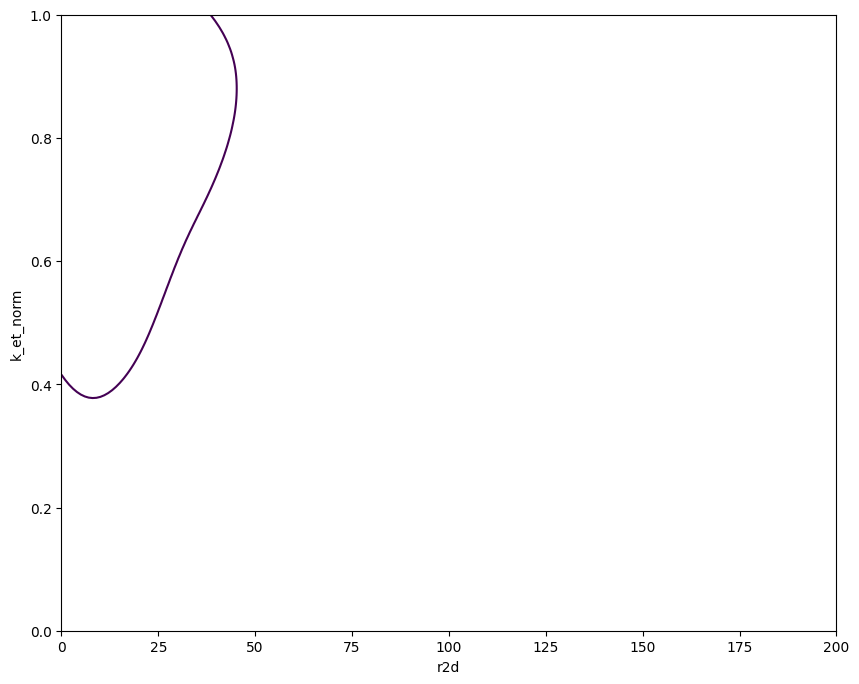

In [24]:
var = "et_norm"
rad = "r2d"

k_drif = 0.8
k_diff = 0.2

cont_level = 0.75
grid_size = 200

cmap = "jet"

xmax = 200
ymax = 1

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=False, sharex=False)

kde_lst = []
for it_id in it_dict:
    x_lst = []
    y_lst = []
    for gcid in it_dict[it_id]:
        x_lst.append(np.abs(it_dict[it_id][gcid][rad + "_avg"]))
        net = it_dict[it_id][gcid]["d" + var + "_net"]
        path = it_dict[it_id][gcid]["d" + var + "_path"]
        k = net / path
        y_lst.append(k)

    if len(x_lst) <= 2:
        continue
    z = get_kde(x_lst, y_lst, (0, xmax), (0, ymax), grid_size)
    kde_lst.append(z)


Z_mean = np.mean(kde_lst, axis=0)

X, Y = np.mgrid[0 : xmax : grid_size * 1j, 0 : ymax : grid_size * 1j]
level = contour_level_from_mass(Z_mean, X, Y, frac=cont_level)
ax.contour(X, Y, Z_mean, levels=[level])

ax.set_xlabel(rad)
ax.set_ylabel("k_" + var)

Text(0, 0.5, 'k_et_norm')

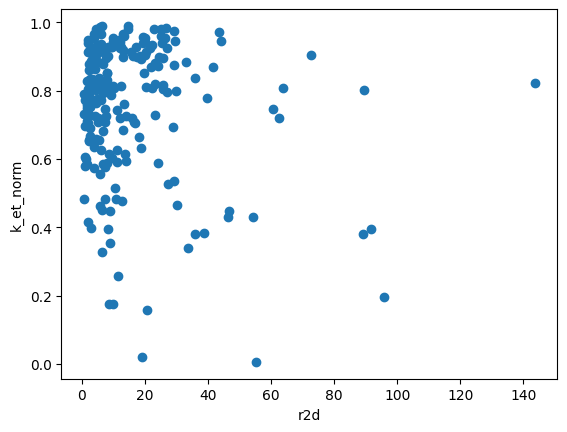

In [25]:
it_id = "it000"

x_lst = []
y_lst = []
for gcid in it_dict[it_id]:
    x_lst.append(it_dict[it_id][gcid][rad + "_avg"])
    net = it_dict[it_id][gcid]["d" + var + "_net"]
    path = it_dict[it_id][gcid]["d" + var + "_path"]
    k = net / path
    y_lst.append(k)

plt.scatter(x_lst, y_lst)

plt.xlabel(rad)
plt.ylabel("k_" + var)

In [30]:
mul = 10

########################################

t_diff = np.median(np.diff(time_lst))

dt = mul * t_diff

win_lst = []

idxl = 0
tl = time_lst[idxl]
tu = np.max(time_lst[time_lst <= tl + dt])
idxu = np.argmin(np.abs(time_lst - tu))

win_lst.append({"idxl": idxl, "idxu": idxu})

while idxu < len(time_lst) - 1:
    idxl += 1
    tl = time_lst[idxl]
    tu = np.max(time_lst[time_lst <= tl + dt])
    idxu = np.argmin(np.abs(time_lst - tu))

    win_lst.append({"idxl": idxl, "idxu": idxu})

In [38]:
def plot_kvar(var, win_lst, it_dict, grp="in_situ"):
    k_avg = []
    k_std = []
    t_hld = []

    for win in win_lst:
        idxl = win["idxl"]
        idxu = win["idxu"]

        t_cen = np.average((time_lst[idxl], time_lst[idxu]))

        tmin = time_lst[idxl]

        it_k = []
        for it_id in it_dict:
            gc_k = []
            for gcid in it_dict[it_id]:
                if it_dict[it_id][gcid]["grp_type"] != grp:
                    continue
                if it_dict[it_id][gcid]["tval"] < tmin:
                    d_arr = it_dict[it_id][gcid]["d" + var]
                    gc_path = np.nansum(np.abs(d_arr[idxl:idxu]))
                    gc_net = np.abs(it_dict[it_id][gcid][var][idxu] - it_dict[it_id][gcid][var][idxl])
                    gc_k.append(gc_net / gc_path)
                else:
                    continue

            if len(gc_k) != 0:
                it_k.append(np.nanmean(gc_k))

        if len(it_k) != 0:
            k_avg.append(np.nanmean(it_k))
            k_std.append(np.nanstd(it_k))
            t_hld.append(t_cen)

    return k_avg, k_std, t_hld

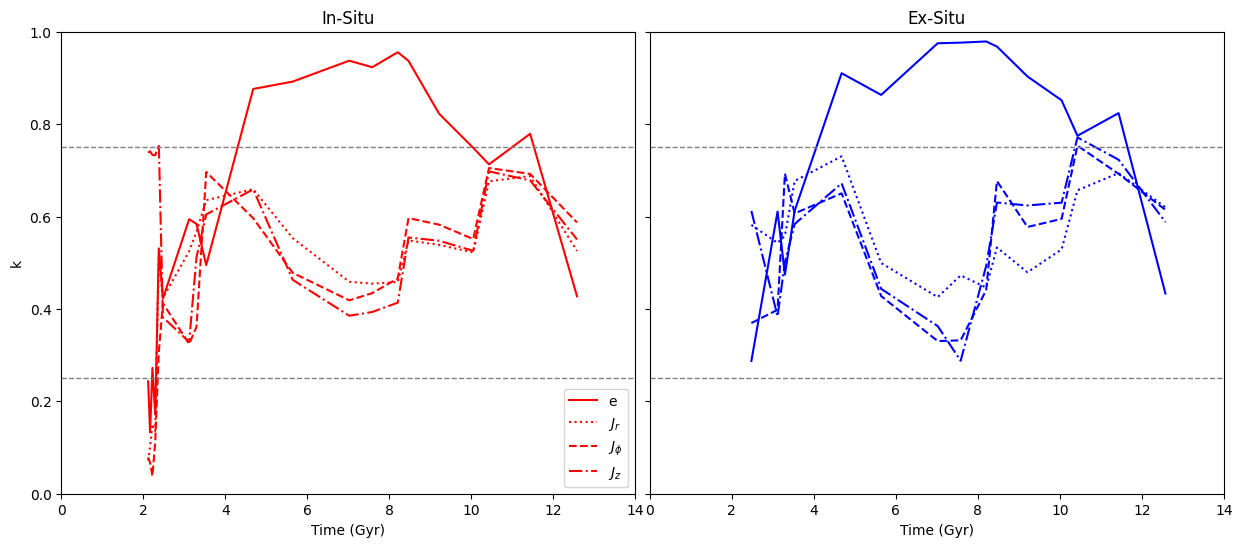

In [54]:
var_lst = ["et_norm", "jr", "jp", "jz"]
plt_lin = ["solid", "dotted", "dashed", "dashdot"]
leg_lst = [r"e", r"$J_{r}$", r"$J_{\phi}$", r"$J_{z}$"]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.025)

for var, lin, leg in zip(var_lst, plt_lin, leg_lst):
    k_avg, k_std, t_hld = plot_kvar(var, win_lst, it_dict, grp="in_situ")
    axs[0].plot(t_hld, k_avg, c="r", ls=lin, label=leg)

    k_avg, k_std, t_hld = plot_kvar(var, win_lst, it_dict, grp="ex_situ")
    axs[1].plot(t_hld, k_avg, c="b", ls=lin)

axs[0].set_ylabel("k")
axs[0].set_xlabel("Time (Gyr)")
axs[1].set_xlabel("Time (Gyr)")

axs[0].set_title("In-Situ")
axs[1].set_title("Ex-Situ")

axs[0].legend(loc="lower right")

for ax in axs:
    ax.plot([0, 14], [0.25, 0.25], c="grey", ls="--", lw=1)
    ax.plot([0, 14], [0.75, 0.75], c="grey", ls="--", lw=1)

    ax.set_xlim(0, 14)
    ax.set_ylim(0, 1)